In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"

matrices = np.load(PROCESSED_DIR / "ati_v1_matrices.npy")
meta = pd.read_parquet(PROCESSED_DIR / "ati_v1_metadata.parquet")

with open(PROCESSED_DIR / "activity_index.json") as f:
    activity_index = json.load(f)
activity_names = list(activity_index.keys())

print("matrices shape:", matrices.shape)
print("meta shape:", meta.shape)
print(meta.head())

matrices shape: (576848, 20, 20)
meta shape: (576848, 5)
  code_module code_presentation  id_student  week  label
0         AAA             2013J       11391     0      0
1         AAA             2013J       11391     1      0
2         AAA             2013J       11391     2      0
3         AAA             2013J       11391     4      0
4         AAA             2013J       11391     5      0


In [2]:
label_by_week = meta.groupby("week")["label"].agg(["mean", "count"])
print(label_by_week)

          mean  count
week                 
0     0.215733  23492
1     0.204371  22968
2     0.188386  23351
3     0.178173  21771
4     0.168820  21360
5     0.155644  20155
6     0.142644  20078
7     0.138976  19766
8     0.129310  18328
9     0.123951  17515
10    0.110843  14507
11    0.106297  13641
12    0.099846  16205
13    0.093565  16908
14    0.088120  16330
15    0.080053  16489
16    0.072485  15962
17    0.063976  16131
18    0.060111  16170
19    0.054986  15404
20    0.049206  15425
21    0.041645  15560
22    0.037242  14983
23    0.031554  14895
24    0.026600  13609
25    0.021425  12462
26    0.018448  12359
27    0.017399  12932
28    0.017097  13219
29    0.013198  13335
30    0.009796  12863
31    0.005781  12801
32    0.005055  12859
33    0.003866  11382
34    0.001276   8624
35    0.000000   4358
36    0.000000   3849
37    0.000000   3228
38    0.000000   1574


In [3]:
idx = 2
print(f"Student {meta.iloc[idx]['id_student']}, week {meta.iloc[idx]['week']}, label {meta.iloc[idx]['label']}")
print(matrices[idx])

Student 11391, week 2, label 0
[[5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02
  5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02
  5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02
  5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02]
 [5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02
  5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02
  5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02
  5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02]
 [5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02
  5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02
  5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02
  5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02]
 [5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02 5.0000001e-02
  5.0000001e-02 5.0000001e-02 

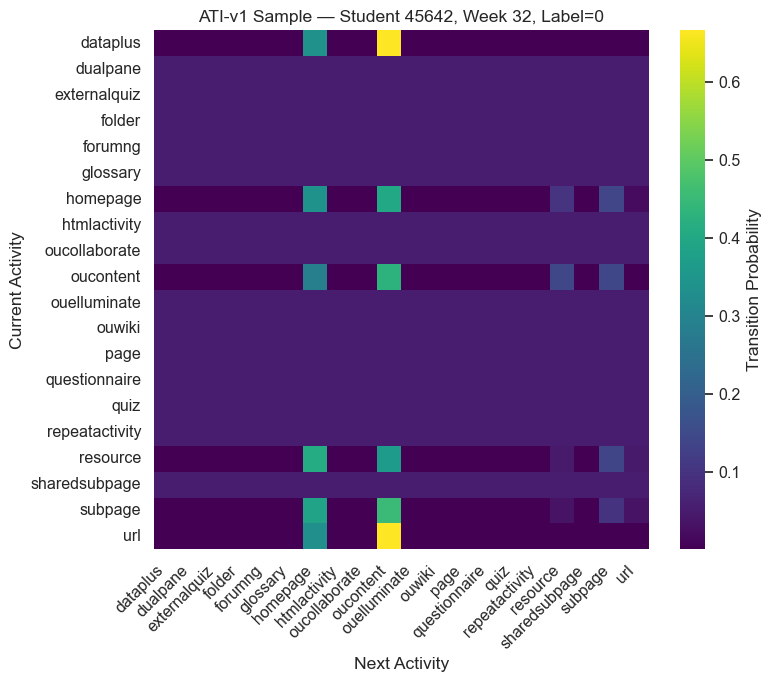

In [7]:
idx = 226
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(matrices[idx], cmap="viridis", xticklabels=activity_names, yticklabels=activity_names,
            cbar_kws={"label": "Transition Probability"}, ax=ax)
ax.set_title(f"ATI-v1 Sample — Student {meta.iloc[idx]['id_student']}, "
             f"Week {meta.iloc[idx]['week']}, Label={meta.iloc[idx]['label']}")
ax.set_xlabel("Next Activity")
ax.set_ylabel("Current Activity")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()